# 51 OLS Linear Regression

Modelos OLS para `sale` y `rent` prediciendo `log_precio`.

**Pipeline:**
1. Eliminación de outliers en `log_precio` con método IQR antes del split
2. Split 80/20 train/test estratificado
3. **Modelo base parsimonioso** — 12 regresores
4. Validación cruzada 5-fold (CV=5): MSE, RMSE, MAE, MAPE y R²
5. VIF para diagnóstico de multicolinealidad
6. Resumen de coeficientes OLS con statsmodels (coef, std err, t, p-value, IC95)
7. Gráficos diagnósticos: Real vs Predicho, residuos, histograma residuos

## Configuracion y carga de datos
Se definen parametros globales, features base y rutas para venta/alquiler.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5
TARGET_COL   = "log_precio"
IQR_FACTOR   = 1.5

# ── Features del modelo base ──────────────────────────────────────────────────
# Solo se incluye tipologia_unificada_unifamiliar para evitar la trampa de las
# variables ficticias (piso es la categoría de referencia implícita).
BASE_FEATURES = [
    "log_superficie_construida_m2",
    "numero_dormitorios",
    "numero_banos",
    "tiene_garaje",
    "obra_nueva",
    "distancia_min_playa_km",
    "distancia_min_supermercado_km",
    "distancia_min_colegio_km",
    "distancia_centro_municipio_km",
    "tipologia_unificada_unifamiliar",
    "precio_m2_municipio_media",
]

# ── Rutas de datos ────────────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "gold").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/gold")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATASETS = {
    "sale": PROJECT_ROOT / "data" / "gold" / "final_sale.csv",
    "rent": PROJECT_ROOT / "data" / "gold" / "final_rent.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"  {name}: {path}")

Datasets listos:
  sale: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_sale.csv
  rent: /Users/sitomachucas/Documents/BezanillaSL/data/gold/final_rent.csv


## Funciones auxiliares
Utilidades para outliers, matriz de features, metricas, VIF y OLS.

In [5]:
# ── Funciones auxiliares ──────────────────────────────────────────────────────

def remove_outliers_iqr(df: pd.DataFrame, col: str = TARGET_COL) -> pd.DataFrame:
    """Elimina outliers en `col` con método IQR antes del split."""
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lower  = q1 - IQR_FACTOR * iqr
    upper  = q3 + IQR_FACTOR * iqr
    mask   = df[col].between(lower, upper)
    n_out  = (~mask).sum()
    print(f"  Rango válido [{col}]: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_out} / {len(df)} ({n_out / len(df) * 100:.1f}%)")
    return df[mask].copy()


def build_X(df: pd.DataFrame) -> pd.DataFrame:
    """Devuelve la matriz de features."""
    features = [f for f in BASE_FEATURES if f in df.columns]
    return df[features].copy()


def compute_metrics(y_true, y_pred, n_features: int) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    n   = len(y_true)
    r2_adj = (
        1 - (1 - r2) * (n - 1) / (n - n_features - 1)
        if n > n_features + 1
        else np.nan
    )
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(r2_adj),
    }


def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    VIF (Variance Inflation Factor) para cada regresor.
    Regla general: VIF > 5 → multicolinealidad moderada; VIF > 10 → severa.
    """
    Xc  = sm.add_constant(X.astype(float))
    vif = pd.DataFrame({
        "feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values.astype(float), i)
                    for i in range(Xc.shape[1])],
    })
    return (
        vif[vif["feature"] != "const"]
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )


def cv_ols_metrics(X: pd.DataFrame, y: pd.Series, n_features: int) -> dict:
    """Validación cruzada 5-fold con LinearRegression (equiv. a OLS)."""
    kf           = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []
    for tr_idx, val_idx in kf.split(X):
        mdl = LinearRegression()
        mdl.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = mdl.predict(X.iloc[val_idx])
        fold_results.append(compute_metrics(y.iloc[val_idx], pred, n_features))
    return {k: float(np.mean([m[k] for m in fold_results])) for k in fold_results[0]}


def fit_ols_statsmodels(X_train: pd.DataFrame, y_train: pd.Series) -> sm.regression.linear_model.RegressionResultsWrapper:
    """Ajusta OLS con statsmodels (incluye constante) sobre el set de train."""
    Xc = sm.add_constant(X_train.astype(float))
    return sm.OLS(y_train, Xc).fit()


def print_coef_summary(result) -> None:
    """Imprime tabla de coeficientes ordenada por magnitud absoluta."""
    coef_df = pd.DataFrame({
        "coef":      result.params,
        "std_err":   result.bse,
        "t":         result.tvalues,
        "p_value":   result.pvalues,
        "IC_95_inf": result.conf_int()[0],
        "IC_95_sup": result.conf_int()[1],
    })
    coef_df = coef_df.drop(index="const", errors="ignore")
    coef_df["|coef|"] = coef_df["coef"].abs()
    coef_df = coef_df.sort_values("|coef|", ascending=False).drop(columns="|coef|")
    print(coef_df.round(5).to_string())


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


## Entrenamiento y evaluacion
Loop por dataset con limpieza, split, VIF, OLS, metricas y graficos diagnosticos.


DATASET: SALE

Filas originales: 588
Detectando outliers en el target:
  Rango válido [log_precio]: [10.9828, 13.8581]
  Outliers eliminados: 6 / 588 (1.0%)
Filas tras limpieza: 582

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 465 | Test: 117

── VIF (train) ─────────────────────────────────────────────────────
                        feature   VIF
   log_superficie_construida_m2 4.340
tipologia_unificada_unifamiliar 2.953
  distancia_min_supermercado_km 2.714
             numero_dormitorios 2.645
       distancia_min_colegio_km 2.439
                   numero_banos 2.209
      precio_m2_municipio_media 2.082
         distancia_min_playa_km 1.784
  distancia_centro_municipio_km 1.447
                   tiene_garaje 1.220
     

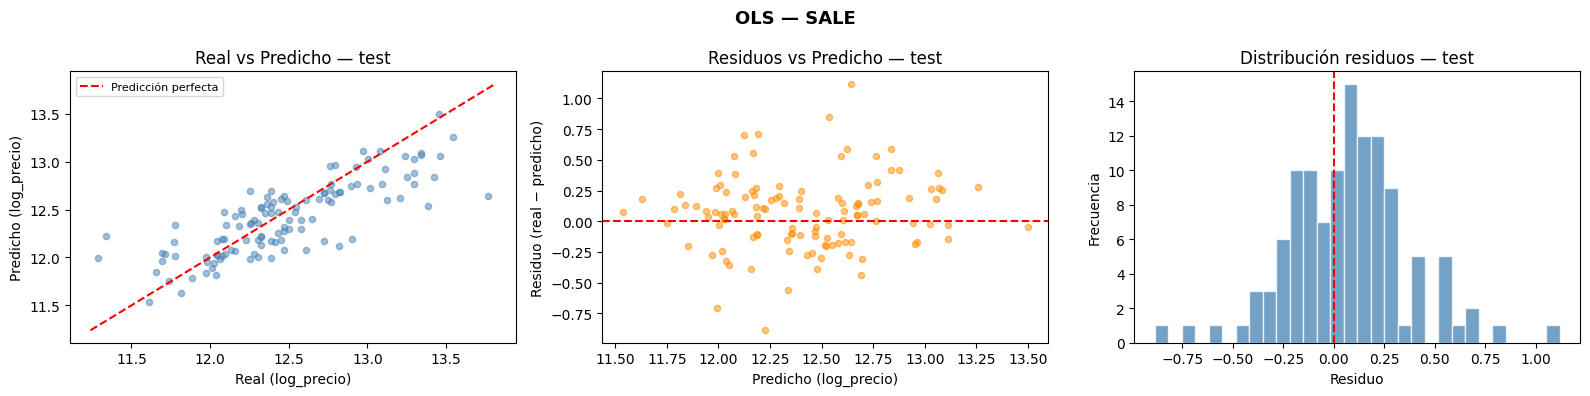


DATASET: RENT

Filas originales: 477
Detectando outliers en el target:
  Rango válido [log_precio]: [6.1079, 7.8074]
  Outliers eliminados: 26 / 477 (5.5%)
Filas tras limpieza: 451

Features (11): ['log_superficie_construida_m2', 'numero_dormitorios', 'numero_banos', 'tiene_garaje', 'obra_nueva', 'distancia_min_playa_km', 'distancia_min_supermercado_km', 'distancia_min_colegio_km', 'distancia_centro_municipio_km', 'tipologia_unificada_unifamiliar', 'precio_m2_municipio_media']
Train: 360 | Test: 91

── VIF (train) ─────────────────────────────────────────────────────
                        feature   VIF
   log_superficie_construida_m2 3.417
             numero_dormitorios 2.590
                   numero_banos 2.143
tipologia_unificada_unifamiliar 1.583
  distancia_min_supermercado_km 1.515
       distancia_min_colegio_km 1.497
      precio_m2_municipio_media 1.199
                   tiene_garaje 1.184
         distancia_min_playa_km 1.174
  distancia_centro_municipio_km 1.129
       

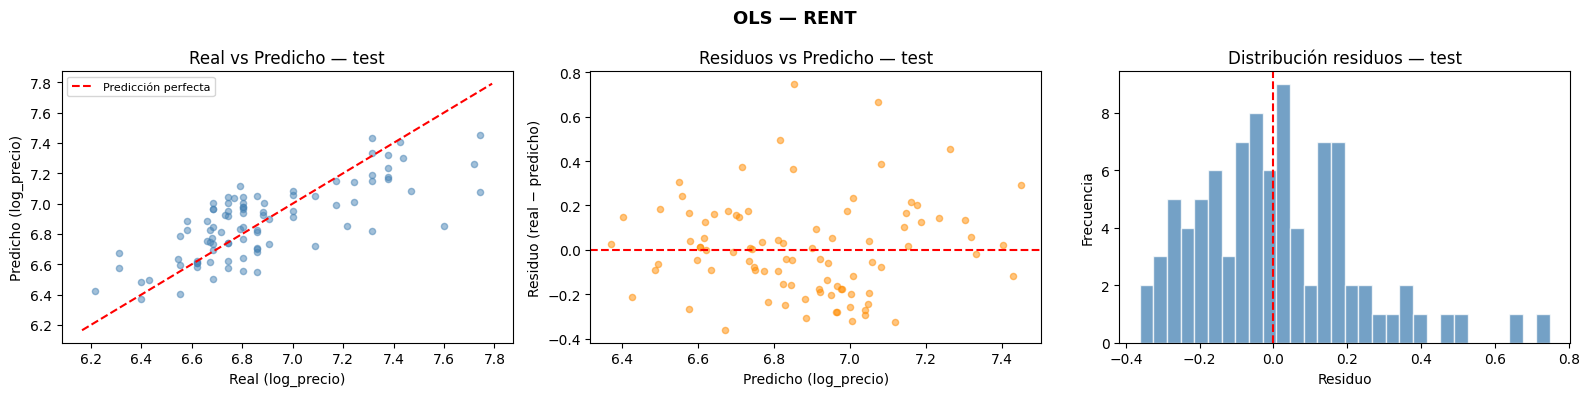


RESUMEN GLOBAL — MODELO BASE OLS
dataset  n_filas  n_features  train_RMSE  train_R2  train_R2_adj  CV_5f_RMSE  CV_5f_R2  test_RMSE  test_R2  test_MAE  test_MAPE  delta_RMSE  delta_R2
   sale      582          11     0.34176   0.61301       0.60361     0.34267   0.59274    0.30206  0.63262   0.22771    0.01816    -0.03970  -0.01962
   rent      451          11     0.20228   0.54897       0.53471     0.21054   0.52386    0.21613  0.56433   0.16674    0.02398     0.01385  -0.01536


,dataset,n_filas,n_features,train_RMSE,train_R2,train_R2_adj,CV_5f_RMSE,CV_5f_R2,test_RMSE,test_R2,test_MAE,test_MAPE,delta_RMSE,delta_R2
0,sale,582,11,0.341756,0.613006,0.603609,0.342668,0.592739,0.302059,0.632624,0.227712,0.018162,-0.039697,-0.019618
1,rent,451,11,0.202278,0.548970,0.534713,0.210543,0.523857,0.216132,0.564327,0.166742,0.023984,0.013854,-0.015357


In [6]:
all_summary_rows = []

for dataset_name, dataset_path in DATASETS.items():
    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}")
    print("=" * 100)

    # ── Carga y limpieza ──────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path)
    df = df[df[TARGET_COL].notna()].copy()
    print(f"\nFilas originales: {len(df)}")

    print("Detectando outliers en el target:")
    df = remove_outliers_iqr(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Construcción de features ──────────────────────────────────────────────
    X = build_X(df)
    y = df[TARGET_COL].copy()

    # Chequeo de NaN en features
    nan_counts = X.isna().sum()
    if nan_counts.any():
        print("\nNaN por feature (se imputarán con mediana):")
        print(nan_counts[nan_counts > 0])
        X = X.fillna(X.median(numeric_only=True))

    n_features = X.shape[1]
    print(f"\nFeatures ({n_features}): {X.columns.tolist()}")

    # ── Split 80/20 ───────────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Train: {len(X_train)} | Test: {len(X_test)}")

    # ── VIF (sobre train) ─────────────────────────────────────────────────────
    print("\n── VIF (train) ─────────────────────────────────────────────────────")
    vif_df = compute_vif(X_train)
    print(vif_df.round(3).to_string(index=False))
    alto_vif = vif_df[vif_df["VIF"] > 5]
    if not alto_vif.empty:
        print(f"\n  ⚠  Variables con VIF > 5: {alto_vif['feature'].tolist()}")
    else:
        print("\n  ✓  Todos los VIF ≤ 5 — sin multicolinealidad problemática.")

    # ── OLS con statsmodels (train) ───────────────────────────────────────────
    ols_result = fit_ols_statsmodels(X_train, y_train)

    # ── Métricas train / test ─────────────────────────────────────────────────
    X_train_c = sm.add_constant(X_train.astype(float))
    X_test_c  = sm.add_constant(X_test.astype(float), has_constant="add")

    pred_train = ols_result.predict(X_train_c)
    pred_test  = ols_result.predict(X_test_c)

    train_m = compute_metrics(y_train, pred_train, n_features)
    test_m  = compute_metrics(y_test,  pred_test,  n_features)

    # ── Validación cruzada 5-fold (sobre todo el dataset limpio) ─────────────
    cv_m = cv_ols_metrics(X, y, n_features)

    # ── Tabla de métricas ─────────────────────────────────────────────────────
    print("\n── Métricas ────────────────────────────────────────────────────────")
    metrics_table = pd.DataFrame([
        {"split": "train",             **train_m},
        {"split": f"CV ({N_SPLITS}-fold)", **cv_m},
        {"split": "test",              **test_m},
    ])
    print(metrics_table.round(5).to_string(index=False))

    overfit_rmse = test_m["RMSE"] - train_m["RMSE"]
    overfit_r2   = train_m["R2"]  - test_m["R2"]
    print(f"\n  delta RMSE test−train : {overfit_rmse:+.5f}")
    print(f"  delta R²   train−test : {overfit_r2:+.5f}")

    # ── Resumen de coeficientes ───────────────────────────────────────────────
    print("\n── Coeficientes OLS (ordenados por |coef|) ─────────────────────────")
    print_coef_summary(ols_result)
    print(f"\n  R² train (statsmodels): {ols_result.rsquared:.5f}")
    print(f"  R² ajustado (statsmodels): {ols_result.rsquared_adj:.5f}")
    print(f"  F-stat: {ols_result.fvalue:.2f}  p-value F: {ols_result.f_pvalue:.2e}")

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals_test = y_test - pred_test

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"OLS — {dataset_name.upper()}", fontsize=13, fontweight="bold")

    # 1. Real vs Predicho (test)
    ax = axes[0]
    ax.scatter(y_test, pred_test, alpha=0.5, s=20, color="steelblue")
    lim = [
        min(y_test.min(), pred_test.min()) - 0.05,
        max(y_test.max(), pred_test.max()) + 0.05,
    ]
    ax.plot(lim, lim, "r--", linewidth=1.5, label="Predicción perfecta")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")
    ax.set_title("Real vs Predicho — test")
    ax.legend(fontsize=8)

    # 2. Residuos vs Predicho (test) — detecta heterocedasticidad
    ax = axes[1]
    ax.scatter(pred_test, residuals_test, alpha=0.5, s=20, color="darkorange")
    ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Predicho (log_precio)")
    ax.set_ylabel("Residuo (real − predicho)")
    ax.set_title("Residuos vs Predicho — test")

    # 3. Histograma de residuos (test)
    ax = axes[2]
    ax.hist(residuals_test, bins=30, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
    ax.set_xlabel("Residuo")
    ax.set_ylabel("Frecuencia")
    ax.set_title("Distribución residuos — test")

    plt.tight_layout()
    plt.show()

    # ── Acumulación para resumen global ───────────────────────────────────────
    all_summary_rows.append({
        "dataset":              dataset_name,
        "n_filas":              len(df),
        "n_features":           n_features,
        "train_RMSE":           train_m["RMSE"],
        "train_R2":             train_m["R2"],
        "train_R2_adj":         train_m["R2_ajustado"],
        f"CV_{N_SPLITS}f_RMSE": cv_m["RMSE"],
        f"CV_{N_SPLITS}f_R2":   cv_m["R2"],
        "test_RMSE":            test_m["RMSE"],
        "test_R2":              test_m["R2"],
        "test_MAE":             test_m["MAE"],
        "test_MAPE":            test_m["MAPE"],
        "delta_RMSE":           overfit_rmse,
        "delta_R2":             overfit_r2,
    })

# ── Resumen global ────────────────────────────────────────────────────────────
print()
print("=" * 100)
print("RESUMEN GLOBAL — MODELO BASE OLS")
print("=" * 100)
summary = pd.DataFrame(all_summary_rows)
print(summary.round(5).to_string(index=False))
summary